## kMeans  

In [1]:
FARTHERST_INITIALIZATION = 1
USE_WITHIN_CLUSTER_SUM_OF_SQUARES = 1
LOAD_UNBALANCE_DATASET = 0

Load data

In [2]:
import numpy as np
import pandas as pd

In [3]:
dataset = "unbalance" if LOAD_UNBALANCE_DATASET else "normal"
separator = " " if LOAD_UNBALANCE_DATASET else "\t"
df = pd.read_csv(f"../inputs/{dataset}.txt", sep=separator, header=None)
print(len(df))

100


In [4]:
df_input = df.copy()

<Axes: xlabel='0', ylabel='1'>

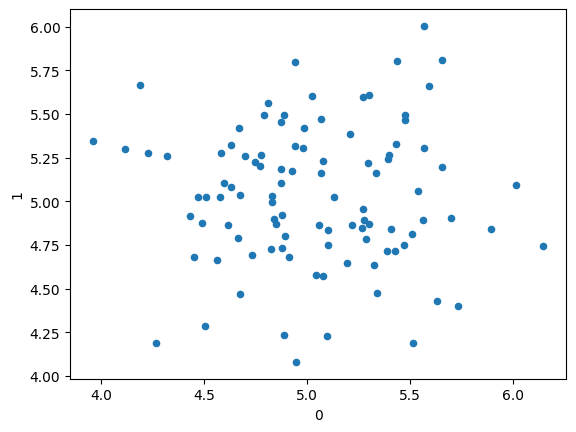

In [5]:
df.plot.scatter(x=0, y=1)

In [6]:
def initialize_centroids_random(df, k):
    centroids = df.sample(n=k).copy()[[0, 1]].reset_index(drop=True)
    return centroids

<Axes: xlabel='0', ylabel='1'>

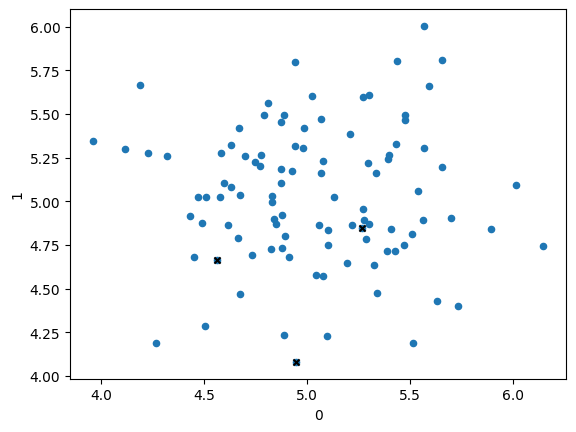

In [7]:
centroids = initialize_centroids_random(df, k=3)
ax = df.plot.scatter(x=0, y=1)
centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

In [8]:
def initialize_centroids_furthest(df, k):
    centroids = df.sample(n=1).copy()[[0, 1]].reset_index(drop=True)

    while len(centroids) < k:
        distances = df.apply(
            lambda row: min(np.linalg.norm(row - centroids.iloc[i]) for i in range(len(centroids))), axis=1
        )

        new_centroid = df.iloc[distances.idxmax()]
        centroids = pd.concat([centroids, new_centroid.to_frame().T], ignore_index=True)

    return centroids

In [9]:
centroids

,0,1
0,4.946,4.081
1,5.268,4.846
2,4.564,4.665


<Axes: xlabel='0', ylabel='1'>

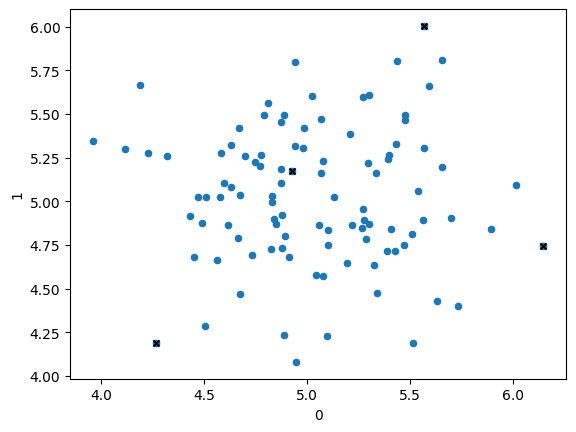

In [10]:
centroids = initialize_centroids_furthest(df, k=4)
ax = df.plot.scatter(x=0, y=1)
centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

In [11]:
def find_closest_centroid(df, centroids):
    distances = pd.DataFrame(index=df.index, columns=centroids.index)

    for i in centroids.index:
        distances[i] = np.linalg.norm(df[[0, 1]] - centroids.loc[i], axis=1)

    return distances.idxmin(axis=1)

In [12]:
closest_centroids = find_closest_centroid(df, centroids)
df["centroids"] = closest_centroids
df

,0,1,centroids
0,5.275,4.893,0
1,5.339,4.476,0
2,4.887,4.234,2
3,5.895,4.843,1
4,4.429,4.915,0
...,...,...,...
95,5.299,5.611,3
96,5.075,4.574,0
97,6.149,4.746,1
98,5.101,4.838,0


<Axes: xlabel='0', ylabel='1'>

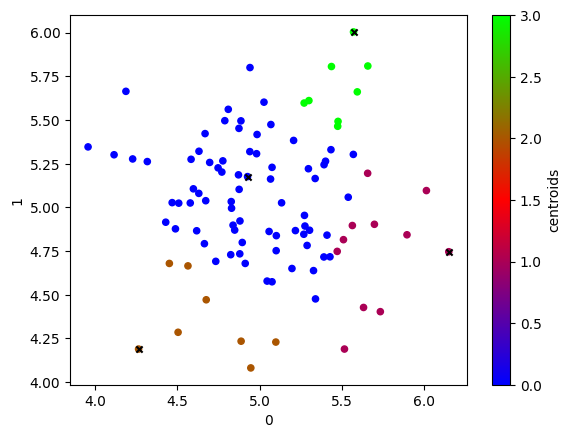

In [13]:
ax = df.plot.scatter(x=0, y=1, c="centroids", colormap="brg")
centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

In [14]:
def replace_centroids(df, centroids):
    new_centroids = pd.DataFrame(index=centroids.index, columns=centroids.columns, dtype=np.float64)

    for i in centroids.index:
        new_centroids.loc[i] = df[df["centroids"] == i].mean()

    return new_centroids

In [15]:
def print_result(df, centroids):
    ax = df.plot.scatter(x=0, y=1, c="centroids", colormap="brg")
    centroids.plot.scatter(x=0, y=1, color="black", ax=ax, marker="x")

          0         1
0  4.921808  5.075959
1  5.712000  4.751000
2  4.673625  4.354125
3  5.471875  5.680500 0    float64
1    float64
dtype: object


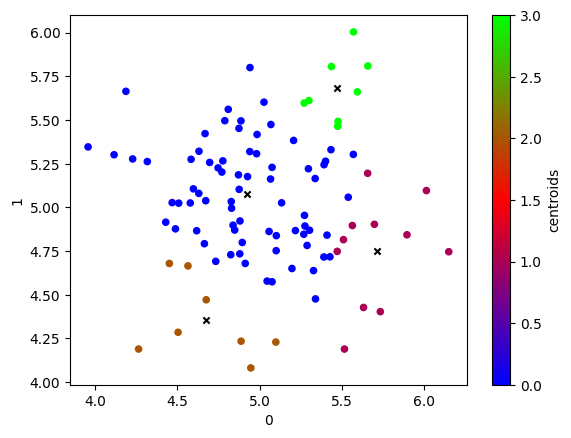

In [16]:
centroids = replace_centroids(df, centroids)
print(centroids, centroids.dtypes)

print_result(df, centroids)

In [17]:
def kmeans(df_input, k, max_iterations=500):
    df = df_input.copy()
    initialization_function = initialize_centroids_furthest if FARTHERST_INITIALIZATION else initialize_centroids_random
    centroids = initialization_function(df, k)

    for i in range(max_iterations + 1):
        if i % 100 == 0:
            print(f"Iteration {i}")

        closest_centroids = find_closest_centroid(df, centroids)
        df["centroids"] = closest_centroids

        new_centroids = replace_centroids(df, centroids)

        if centroids.equals(new_centroids):
            break

        centroids = new_centroids

    return df, centroids

Iteration 0


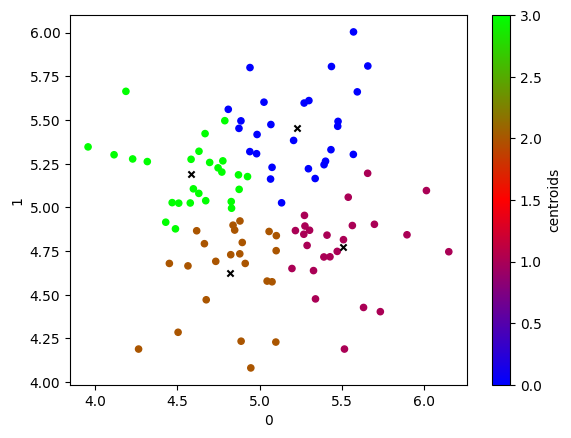

In [18]:
df, centroids = kmeans(df_input, k=4)
print_result(df, centroids)

In [19]:
def get_within_cluster_sum_of_squares(df, centroids):
    wcss = 0

    for i in centroids.index:
        cluster_points = df[df["centroids"] == i].iloc[:, :-1]
        centroid = centroids.loc[i].values
        wcss += np.sum(np.linalg.norm(cluster_points - centroid, axis=1) ** 2)

    return wcss

In [20]:
get_within_cluster_sum_of_squares(df, centroids)

10.770778534265451

In [21]:
def get_mean_intra_cluster_distance(df, centroids):
    distances = pd.DataFrame(index=centroids.index, columns=["mean_distance"])

    for i in centroids.index:
        cluster_points = df[df["centroids"] == i].iloc[:, :-1]
        centroid = centroids.loc[i].values
        distances.loc[i] = np.mean(np.linalg.norm(cluster_points - centroid, axis=1))

    return distances.mean().astype(np.float64).values[0]

In [22]:
get_mean_intra_cluster_distance(df, centroids)

0.29436692179756063

In [23]:
def random_restart_knn(df_input, k, max_iterations=500, restarts=3):
    metric_function = (
        get_within_cluster_sum_of_squares if USE_WITHIN_CLUSTER_SUM_OF_SQUARES else get_mean_intra_cluster_distance
    )

    best_metric = float("inf")
    best_df = None
    best_centroids = None

    for i in range(restarts):
        df, centroids = kmeans(df_input, k, max_iterations)
        current_metric = metric_function(df, centroids)

        print(current_metric, best_metric)
        if current_metric < best_metric:
            best_metric = current_metric
            best_df = df
            best_centroids = centroids

    return best_df, best_centroids

Iteration 0
5.18900265064935 inf
Iteration 0
5.581698288302276 5.18900265064935
Iteration 0
5.9936458477889225 5.18900265064935


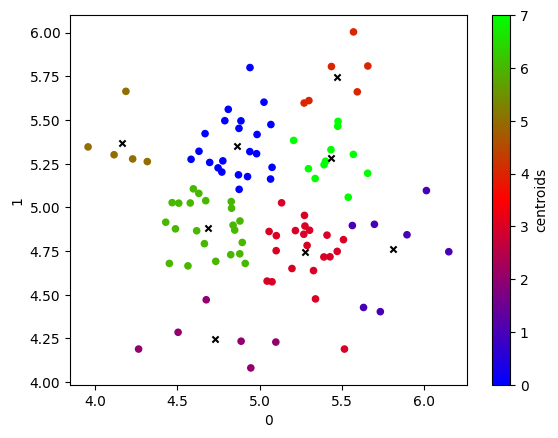

In [24]:
best_df, best_centroids = random_restart_knn(df_input, k=8, restarts=3)
print_result(best_df, best_centroids)

In [25]:
def elbow_method(df_input, k_max=10, max_iterations=500, restarts=3):
    metric_function = (
        get_within_cluster_sum_of_squares if USE_WITHIN_CLUSTER_SUM_OF_SQUARES else get_mean_intra_cluster_distance
    )

    metric_values = []

    for k in range(2, k_max + 1):
        print(f"\nCalculating for k={k}")
        df_best, best_centroids = random_restart_knn(df_input, k, max_iterations, restarts=restarts)
        metric_values.append((k, metric_function(df_best, best_centroids)))

    return metric_values

In [26]:
metric_values = elbow_method(df_input)
metric_values


Calculating for k=2
Iteration 0
21.70681974959742 inf
Iteration 0
21.70681974959742 21.70681974959742
Iteration 0
21.70681974959742 21.70681974959742

Calculating for k=3
Iteration 0
15.93671957339524 inf
Iteration 0
14.842643699855698 15.93671957339524
Iteration 0
15.302937838618982 14.842643699855698

Calculating for k=4
Iteration 0
10.698142850020187 inf
Iteration 0
10.698142850020187 10.698142850020187
Iteration 0
10.740510512228258 10.698142850020187

Calculating for k=5
Iteration 0
9.366103136887304 inf
Iteration 0
9.471734790726815 9.366103136887304
Iteration 0
9.341797255966148 9.366103136887304

Calculating for k=6
Iteration 0
8.034896147651892 inf
Iteration 0
7.753794950707687 8.034896147651892
Iteration 0
7.724693400638277 7.753794950707687

Calculating for k=7
Iteration 0
7.267227102361854 inf
Iteration 0
6.210505770115028 7.267227102361854
Iteration 0
6.050075693845283 6.210505770115028

Calculating for k=8
Iteration 0
5.581698288302276 inf
Iteration 0
5.595912352361853 5

[(2, 21.70681974959742),
 (3, 14.842643699855698),
 (4, 10.698142850020187),
 (5, 9.341797255966148),
 (6, 7.724693400638277),
 (7, 6.050075693845283),
 (8, 5.581698288302276),
 (9, 4.678005278771227),
 (10, 4.109076091125539)]

We can see that the best value is somewhere around k=4 or k=5 for the normal and 8 for the unbalanced

    k     metric
0   2  21.706820
1   3  14.842644
2   4  10.698143
3   5   9.341797
4   6   7.724693
5   7   6.050076
6   8   5.581698
7   9   4.678005
8  10   4.109076


<Axes: xlabel='k'>

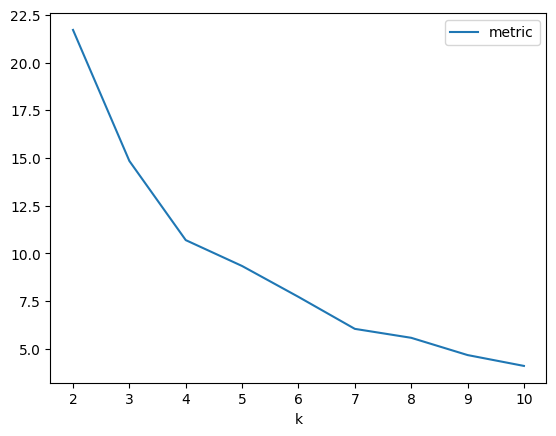

In [27]:
df_metric_values = pd.DataFrame(metric_values, columns=["k", "metric"])
print(df_metric_values)
df_metric_values.plot(x="k", y="metric", kind="line")

Iteration 0
9.412366638120702 inf
Iteration 0
9.053263059955771 9.412366638120702
Iteration 0
9.09092928770087 9.053263059955771
Iteration 0
9.5913074512225 9.053263059955771
Iteration 0
9.577868254070003 9.053263059955771
Iteration 0
9.053263059955771 9.053263059955771
Iteration 0
9.07234105896529 9.053263059955771
Iteration 0
9.630325700702073 9.053263059955771
Iteration 0
9.06002476979704 9.053263059955771
Iteration 0
9.630325700702073 9.053263059955771


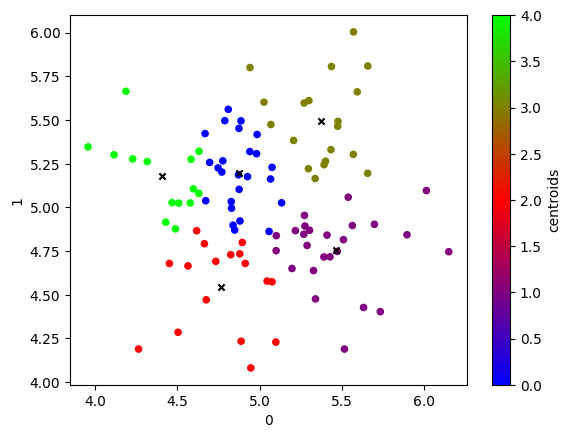

In [28]:
best_df, best_centroids = random_restart_knn(df_input, k=5, restarts=10)
print_result(best_df, best_centroids)